# Random Forest Classifier for Benign or Malignant cells
Objective:
Build a random forest classification algorithm, which is an ensemble machine learning algorithm that uses multiple decision trees to classify data by aggregating the predictions from various decision trees.

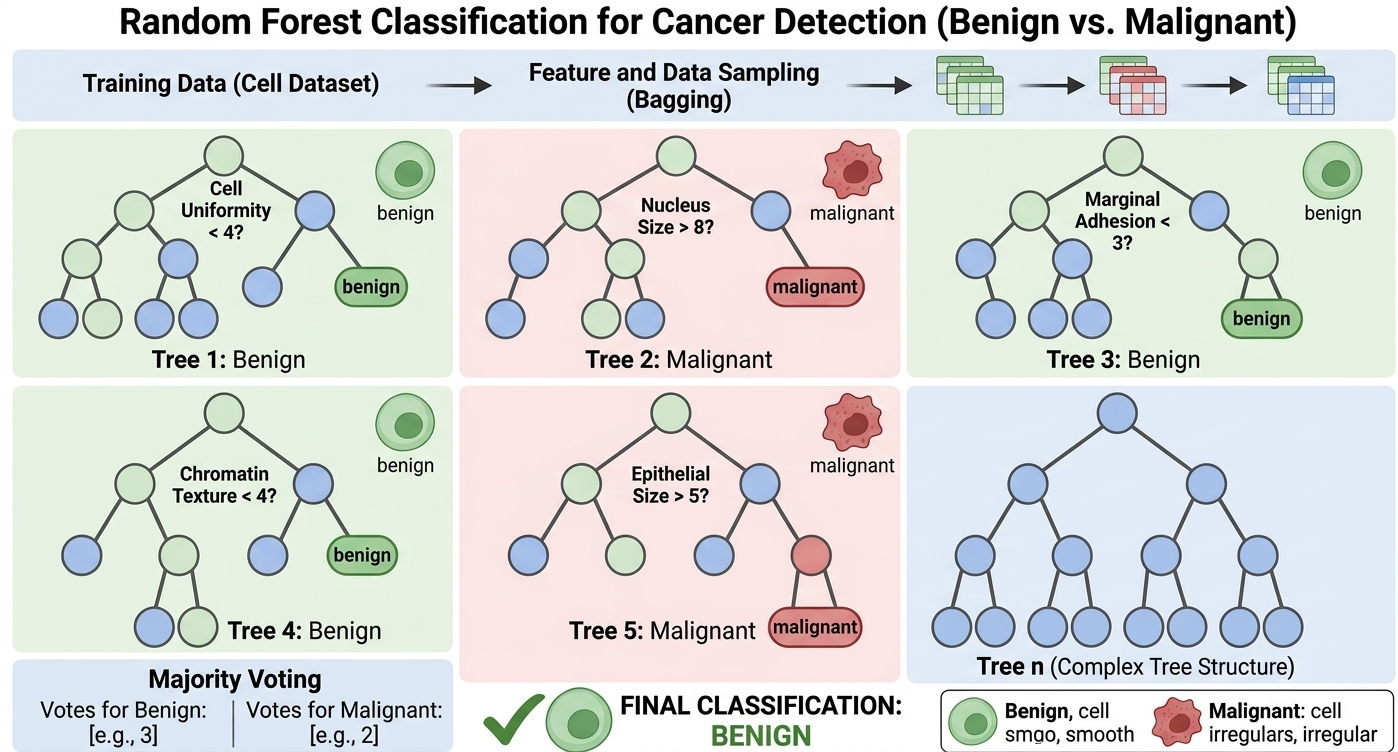

**A Random Forest Classifier main features**
* Automatic Feature Selction that creates Rule Decision tree branches.
*   Decision Paths: They often visually separate the binary splits (e.g., the "Yes" vs. "No" / "True" vs. "False" branches) resulting from a rule at a previous node.

*   Class Predominance: In some models, the color of a node shifts based on which class (e.g., Cat vs. Dog, or Benign vs. Malignant) makes up the majority of the data at that specific point in the tree.

*   Leaf Outcomes: At the bottom of the trees, different colors are used to denote the final predicted class for that specific path.

# Load Sample and Target Datasets
Split between a training and a target dataset for later testing accuracy.

In [0]:
# Install MLFlow for tracking ML model experiments
# Install ssckit learn for ML training = machine learning library
# Requests is for making HTTP calls (e.g. querying an API)
!pip install -q mlflow scikit-learn requests
import pandas as pd
from sklearn.datasets import load_breast_cancer # Load sample dataset
from sklearn.model_selection import train_test_split # utility to split our data

# Load Data
data = load_breast_cancer()
print(type(data))  # <class 'sklearn.utils._bunch.Bunch'>
print(data.keys())  # dict_keys(['data', 'target', 'feature_names', 'target_names', 'DESCR'])
# Features (predictors, measurements or independent variables) are explicitly provided during training
## INPUTS
# X: means all 30 features measurements, what we measure to predict malignancy
X = pd.DataFrame(data.data, # Feature matrix measurements inputs values df['col_1','col_2']
                 columns=data.feature_names # column names output values 1/0
                 )
# Y: all diagnoses labels (0 = malignant, 1 = benign), what we're trying to predict
y = data.target # labels (target, dependent variable, outcomes) df['target_col_name']
## OUTPUTS
'''
We set aside 20% of the data sample, to evaluate the model's performance on
unseen labels
x_train: 75% of the data sample features used to train the model.
x_test: 25% of the data sample saved to test accuracy vs labels
y_train: 75% of the data sample labels used to train the model.
y_test: 25% of the data sample saved to test accuracy vs features
This helps test the model's ability to generalize to new data not seen before during training to understand if it truly learned patterns.
'''
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
print(f"Training data shape: {X_train.shape}")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Training data shape: (455, 30)


# Train and Track with MLflow
We will use MLflow's autolog() feature, which automatically records hyperparameters, metrics (like accuracy and F1), and the model artifact itself without writing manual tracking code.
We'll run a simple loop to simulate hyperparameter tuning and create an initial mlflow database table to store all the metrics parameters as a mlflow.db database file.



In [0]:
import mlflow
import mlflow.sklearn # Module for logging ML models built with scikit-learn
# import algorithm that uses many decision trees to vote on a classification.
from sklearn.ensemble import RandomForestClassifier

# Enable automatic logging for scikit-learn
'''this tells MLflow to automatically watch our training and record things
like accuracy, training time, and model parameters for us.
Captures the model itself, hyperparameters used, performance metrics'''
mlflow.sklearn.autolog() # MLflow autologs metrics test accuracy evaluation

# Set up and initiate a MLflow experiment
''' Every run we perform will be saved by this specific experiment name in the UI'''
mlflow.set_experiment("/Breast_Cancer_Classification")

# Run multiple experiments with different hyperparameters
n_estimators_list = [50, 100, 200] # 3 versions or decision trees models variations
'''
Hyperparameter Testing matters to find the optimal number of trees. More trees is better accuracy but slower training. Usually we test the accuracy of the variations to determine the sweet spot betwen speed and accuracy.
'''
for n in n_estimators_list:
    with mlflow.start_run(run_name=f"RF_estimators_{n}"): # Run entry log name
        model = RandomForestClassifier(n_estimators=n, # Number of decision trees built in the model
                                       random_state=42)
        # Teaching process where model learns the patterns between features and target
        '''
        Automatic Feature Selction that creates Rule Decision tree branches:
        Builds a decision tree that learn rules like if x_col > 10 AND y_col < 5 THEN label predict = 1
        '''
        model.fit(X_train, y_train) # Learning patterns between features and target labels
        # We test model on 20% of unseen new data to asssess it
        accuracy = model.score(X_test, y_test)
        print(f"Trained model with {n} estimators. Accuracy: {accuracy:.4f}")

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
🔗 View Logged Model at: https://dbc-95cead1c-bd86.cloud.databricks.com/ml/experiments/68040414070072/models/m-c7a38deaff1a4c15a93e8fa2c8c9b204?o=7474658970196910


Trained model with 50 estimators. Accuracy: 0.9649


🔗 View Logged Model at: https://dbc-95cead1c-bd86.cloud.databricks.com/ml/experiments/68040414070072/models/m-5f014aca1d564eec874c2754fbef9684?o=7474658970196910


Trained model with 100 estimators. Accuracy: 0.9649


🔗 View Logged Model at: https://dbc-95cead1c-bd86.cloud.databricks.com/ml/experiments/68040414070072/models/m-a132f88dab5e4e1db3c71d6e2da9f47a?o=7474658970196910


Trained model with 200 estimators. Accuracy: 0.9649


# Building Each Decision Tree

For each tree, the algorithm recursively builds splits:
Example Tree Construction:
IF worst concave points > 0.08? 
│  IF YES → worst area > 600?
│  │  IF YES → MALIGNANT (0)
│  │  IF NO → BENIGN (1)
│  └─ IF → mean radius > 12?
│     ├─ IF → BENIGN (1)
│     └─ IF → BENIGN (1)

#Explore the MLflow UI
In Databricks, the UI is built-in. In another IDE, we can view it right inside the notebook using a magic command to compare our runs and decide which model is the best or run it manually in MLFLow interface.

![image_1783973410394.png](./image_1783973410394.png "image_1783973410394.png")

![image_1783973445447.png](./image_1783973445447.png "image_1783973445447.png")

# Register and Serve the Model
Now we select the best run and register it. Here, we use MLflow's local registry. 
We will then spin up a REST API endpoint in the background.

In [0]:
# Find the best model (sorting by test_score)
best_run = mlflow.search_runs(
    experiment_names=["/Breast_Cancer_Classification"],
    order_by=["metrics.training_score DESC"]
).iloc[0]

best_run_id = best_run.run_id
model_uri = f"runs:/{best_run_id}/model"

print(f"Registering Best Run ID: {best_run_id}")

# Register the model
# Note:  we can also register manually the model
mlflow.register_model(model_uri, "Champion_Cancer_Model")

Registering Best Run ID: 984b36b72f3645878469fe7420637d56


Successfully registered model 'workspace.default.champion_cancer_model'.
2026/07/13 20:20:38 WARNING mlflow.tracking._model_registry.fluent: Run with id 984b36b72f3645878469fe7420637d56 has no artifacts at artifact path 'model', registering model based on models:/m-9046212b4ee44d45b1089f78b2da4bd5 instead


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.champion_cancer_model': https://dbc-95cead1c-bd86.cloud.databricks.com/explore/data/models/workspace/default/champion_cancer_model/version/1?o=7474658970196910


<ModelVersion: aliases=[], creation_timestamp=1783974041573, current_stage=None, deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1783974043018, metrics=[<Metric: dataset_digest='665e0e8f', dataset_name='dataset', key='training_precision_score', model_id='m-9046212b4ee44d45b1089f78b2da4bd5', run_id='984b36b72f3645878469fe7420637d56', step=0, timestamp=1783973601712, value=1.0>,
 <Metric: dataset_digest='665e0e8f', dataset_name='dataset', key='training_recall_score', model_id='m-9046212b4ee44d45b1089f78b2da4bd5', run_id='984b36b72f3645878469fe7420637d56', step=0, timestamp=1783973601712, value=1.0>,
 <Metric: dataset_digest='665e0e8f', dataset_name='dataset', key='training_f1_score', model_id='m-9046212b4ee44d45b1089f78b2da4bd5', run_id='984b36b72f3645878469fe7420637d56', step=0, timestamp=1783

In [0]:
# See experiments
runs_df = mlflow.search_runs(experiment_names=["/Breast_Cancer_Classification"])
display(runs_df)

run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_f1_score,metrics.training_roc_auc,metrics.training_recall_score,metrics.training_score,metrics.training_accuracy_score,metrics.training_precision_score,metrics.training_log_loss,metrics.RandomForestClassifier_score_X_test,params.oob_score,params.bootstrap,params.monotonic_cst,params.class_weight,params.min_weight_fraction_leaf,params.min_samples_leaf,params.max_features,params.min_samples_split,params.ccp_alpha,params.criterion,params.random_state,params.min_impurity_decrease,params.max_depth,params.verbose,params.max_samples,params.warm_start,params.n_estimators,params.n_jobs,params.max_leaf_nodes,tags.mlflow.databricks.cluster.info,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.estimator_name,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.workspaceURL,tags.mlflow.databricks.notebookRevisionID,tags.mlflow.databricks.cluster.libraries,tags.mlflow.databricks.cluster.id,tags.estimator_class,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.notebookPath,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.webappURL,tags.mlflow.source.type
984b36b72f3645878469fe7420637d56,68040414070072,FINISHED,dbfs:/databricks/mlflow-tracking/68040414070072/984b36b72f3645878469fe7420637d56/artifacts,2026-07-13T20:13:16.908Z,2026-07-13T20:13:23.294Z,1.0,1.0,1.0,1.0,1.0,1.0,0.034713417175914335,0.9649122807017544,False,True,None,None,0.0,1,sqrt,2,0.0,gini,42,0.0,None,0,None,False,200,None,None,"{""cluster_name"":"""",""spark_version"":""client.5.8-aarch64-scala2.13"",""autotermination_minutes"":120}",mattia.maroni.aguilar@gmail.com,/Users/mattia.maroni.aguilar@gmail.com/MLOps_pipeline_health_detector,RF_estimators_200,RandomForestClassifier,#479a5f,1001783973275235_7171065607099684079_723a5bd607ea475eb18adfa39da968e0,https://dbc-95cead1c-bd86.cloud.databricks.com,1783973603389,"{""installable"":[],""redacted"":[]}",0713-201117-fupdcf6d-v2n,sklearn.ensemble._forest.RandomForestClassifier,68040414070071,/Users/mattia.maroni.aguilar@gmail.com/MLOps_pipeline_health_detector,7474658970196910,https://dbc-95cead1c-bd86.cloud.databricks.com,NOTEBOOK
6f71a48983ff4936abfdd34b7b2296a1,68040414070072,FINISHED,dbfs:/databricks/mlflow-tracking/68040414070072/6f71a48983ff4936abfdd34b7b2296a1/artifacts,2026-07-13T20:13:10.097Z,2026-07-13T20:13:16.767Z,1.0,1.0,1.0,1.0,1.0,1.0,0.03565585219317046,0.9649122807017544,False,True,None,None,0.0,1,sqrt,2,0.0,gini,42,0.0,None,0,None,False,100,None,None,"{""cluster_name"":"""",""spark_version"":""client.5.8-aarch64-scala2.13"",""autotermination_minutes"":120}",mattia.maroni.aguilar@gmail.com,/Users/mattia.maroni.aguilar@gmail.com/MLOps_pipeline_health_detector,RF_estimators_100,RandomForestClassifier,#da4c4c,1001783973275235_7171065607099684079_723a5bd607ea475eb18adfa39da968e0,https://dbc-95cead1c-bd86.cloud.databricks.com,1783973596852,"{""installable"":[],""redacted"":[]}",0713-201117-fupdcf6d-v2n,sklearn.ensemble._forest.RandomForestClassifier,68040414070071,/Users/mattia.maroni.aguilar@gmail.com/MLOps_pipeline_health_detector,7474658970196910,https://dbc-95cead1c-bd86.cloud.databricks.com,NOTEBOOK
86dcb9c6d9884993b94193c46b55a32a,68040414070072,FINISHED,dbfs:/databricks/mlflow-tracking/68040414070072/86dcb9c6d9884993b94193c46b55a32a/artifacts,2026-07-13T20:12:59.629Z,2026-07-13T20:13:09.957Z,1.0,1.0,1.0,1.0,1.0,1.0,0.036249263361280294,0.9649122807017544,False,True,None,None,0.0,1,sqrt,2,0.0,gini,42,0.0,None,0,None,False,50,None,None,"{""cluster_name"":"""",""spark_version"":""client.5.8-aarch64-scala2.13"",""autotermination_minutes"":120}",mattia.maroni.aguilar@gmail.com,/Users/mattia.maroni.aguilar@gmail.com/MLOps_pipeline_health_detector,RF_estimators_50,RandomForestClassifier,#5387dd,1001783973275235_7171065607099684079_723a5bd607ea475eb18adfa39da968e0,https://dbc-95cead1c-bd86.cloud.databricks.com,1783973590069,"{""installable"":[],""redacted"":[]}",0713-201117-fupdcf6

# Create a serving Endpoint
Can be done manually or with code.

![image_1783974559782.png](./image_1783974559782.png "image_1783974559782.png")

# Load and Query model for testing use

In [0]:
import mlflow.pyfunc

# Load the registered model directly (instead of querying REST endpoint)
model_name = "default.champion_cancer_model"
model_version = 1
loaded_model = mlflow.pyfunc.load_model(f"models:/{model_name}/{model_version}")

# Grab the first row of our test data to predict
sample_data = X_test.iloc[[0]]

# Make prediction directly
prediction = loaded_model.predict(sample_data) # Calling the model.predict() each tree votes, and the majority classification wins
print("Sample Input:")
display(sample_data)
print("Prediction Response:", prediction)

Sample Input:


mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
12.47,18.6,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,0.3961,1.044,2.497,30.29,0.006953,0.01911,0.02701,0.01037,0.01782,0.003586,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875


Prediction Response: [1]


MLflow model is ultimately just a folder containing configuration files (like MLmodel, conda.yaml) and the saved model weights (model.pkl)

# Download Model artifacts assets

In [0]:
# Get model path
import mlflow
# Retrieve the best run ID from the experiment
best_run = mlflow.search_runs(
    experiment_names=["/Breast_Cancer_Classification"],
    order_by=["metrics.training_score DESC"]
).iloc[0]
best_run_id = best_run.run_id

local_path = mlflow.artifacts.download_artifacts(run_id=best_run_id)
# Save files into current directory of this notebook
model_path = local_path + "/model_artifacts"
print("Model saved to:", model_path)

Model saved to: /local_disk0/user_tmp_data/spark-227ca951-2a08-4bda-810e-72/tmp7fyzvkjq//model_artifacts


In [0]:
import shutil
import os

# The ephemeral path from Cell 19
source_path = "/local_disk0/user_tmp_data/spark-227ca951-2a08-4bda-810e-72/tmp7fyzvkjq/"

# Create a persistent location in your workspace
workspace_path = "/Workspace/Users/username/mlflow_cancer_model"

# Copy the entire model directory to workspace
if os.path.exists(source_path):
    # Remove existing directory if it exists
    if os.path.exists(workspace_path):
        shutil.rmtree(workspace_path)
    
    # Copy the model artifacts
    shutil.copytree(source_path, workspace_path)
    print(f"Model artifacts copied to: {workspace_path}")
else:
    print("Source path not found.")

✓ Model artifacts copied to: /Workspace/Users/mattia.maroni.aguilar@gmail.com/mlflow_cancer_model

You can now download this folder from Databricks Workspace:
  Workspace → Users → mattia.maroni.aguilar@gmail.com → mlflow_cancer_model


In [0]:
# Create a clean, portable model package
import json
import mlflow

model_package_path = "/Workspace/Users/username/cancer_model_package"
os.makedirs(model_package_path, exist_ok=True)

# Download the model artifact specifically from MLflow
best_run = mlflow.search_runs(
    experiment_names=["/Breast_Cancer_Classification"],
    order_by=["metrics.training_score DESC"]
).iloc[0]
best_run_id = best_run.run_id

# Download model to temp location
model_temp = mlflow.artifacts.download_artifacts(
    run_id=best_run_id,
    artifact_path="model"
)

# Copy to persistent package location
shutil.copytree(
    model_temp,
    os.path.join(model_package_path, "model"),
    dirs_exist_ok=True
)

# Create requirements.txt for external environments
requirements = """mlflow>=2.0.0
scikit-learn>=1.0.0
pandas>=1.3.0
numpy>=1.21.0
"""

with open(os.path.join(model_package_path, "requirements.txt"), "w") as f:
    f.write(requirements)

# Create a README with usage instructions
readme = f"""# Cancer Prediction Model

## Model Information
- Type: Random Forest Classifier
- Task: Binary classification (Benign vs Malignant)
- Training Accuracy: {accuracy:.4f}

## Usage

### Install dependencies:
```bash
pip install -r requirements.txt
```

### Load and use the model:
```python
import mlflow.pyfunc
import pandas as pd

# Load model
model = mlflow.pyfunc.load_model("./model")

# Make predictions
# Input: 30 features from breast cancer dataset
sample_data = pd.DataFrame(...)
prediction = model.predict(sample_data)
```

## Files
- `model/` - MLflow model artifacts
- `requirements.txt` - Python dependencies
- `README.md` - This file
"""

with open(os.path.join(model_package_path, "README.md"), "w") as f:
    f.write(readme)

print(f"Standalone model package created at: {model_package_path}")
print(f"\nContents:")
for root, dirs, files in os.walk(model_package_path):
    level = root.replace(model_package_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

✓ Standalone model package created at: /Workspace/Users/mattia.maroni.aguilar@gmail.com/cancer_model_package

Contents:
cancer_model_package/
  requirements.txt
  README.md
  model/
    registered_model_meta
    conda.yaml
    requirements.txt
    model.pkl
    python_env.yaml
    ... and 1 more files
    metadata/
      conda.yaml
      requirements.txt
      python_env.yaml
      MLmodel


# Test Model upload to Databricks

In [0]:
# Load the registered model from Databricks Model Registry
'''
This model contain all the weights and parameters of the model and its split rules learned during training (e.g if x > 10 then y = 1), class predictions and feature thresholds.
'''
import mlflow.pyfunc
model_uri = "models:/workspace.default.champion_cancer_model/1"
model = mlflow.pyfunc.load_model(model_uri)

# Use the same test data as before
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Make predictions by running all the treess in parallel and aggregativ the votes (majority vote)
y_pred = model.predict(X_test)

# Combine features, actual, and predicted labels
results_df = X_test.copy()
results_df['Actual_Label'] = y_test
results_df['Predicted_Label'] = y_pred

display(results_df)

mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual_Label,Predicted_Label
12.47,18.6,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,0.3961,1.044,2.497,30.29,0.006953,0.01911,0.02701,0.01037,0.01782,0.003586,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,1,1
18.94,21.31,123.6,1130.0,0.09009,0.1029,0.108,0.07951,0.1582,0.05461,0.7888,0.7975,5.486,96.05,0.004444,0.01652,0.02269,0.0137,0.01386,0.001698,24.86,26.58,165.9,1866.0,0.1193,0.2336,0.2687,0.1789,0.2551,0.06589,0,0
15.46,19.48,101.7,748.9,0.1092,0.1223,0.1466,0.08087,0.1931,0.05796,0.4743,0.7859,3.094,48.31,0.00624,0.01484,0.02813,0.01093,0.01397,0.002461,19.26,26.0,124.9,1156.0,0.1546,0.2394,0.3791,0.1514,0.2837,0.08019,0,0
12.4,17.68,81.47,467.8,0.1054,0.1316,0.07741,0.02799,0.1811,0.07102,0.1767,1.46,2.204,15.43,0.01,0.03295,0.04861,0.01167,0.02187,0.006005,12.88,22.91,89.61,515.8,0.145,0.2629,0.2403,0.0737,0.2556,0.09359,1,1
11.54,14.44,74.65,402.9,0.09984,0.112,0.06737,0.02594,0.1818,0.06782,0.2784,1.768,1.628,20.86,0.01215,0.04112,0.05553,0.01494,0.0184,0.005512,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,1,1
20.6,29.33,140.1,1265.0,0.1178,0.277,0.3514,0.152,0.2397,0.07016,0.726,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.74,39.42,184.6,1821.0,0.165,0.8681,0.9387,0.265,0.4087,0.124,0,0
22.01,21.9,147.2,1482.0,0.1063,0.1954,0.2448,0.1501,0.1824,0.0614,1.008,0.6999,7.561,130.2,0.003978,0.02821,0.03576,0.01471,0.01518,0.003796,27.66,25.8,195.0,2227.0,0.1294,0.3885,0.4756,0.2432,0.2741,0.08574,0,0
17.57,15.05,115.0,955.1,0.09847,0.1157,0.09875,0.07953,0.1739,0.06149,0.6003,0.8225,4.655,61.1,0.005627,0.03033,0.03407,0.01354,0.01925,0.003742,20.01,19.52,134.9,1227.0,0.1255,0.2812,0.2489,0.1456,0.2756,0.07919,0,0
13.34,15.86,86.49,520.0,0.1078,0.1535,0.1169,0.06987,0.1942,0.06902,0.286,1.016,1.535,12.96,0.006794,0.03575,0.0398,0.01383,0.02134,0.004603,15.53,23.19,96.66,614.9,0.1536,0.4791,0.4858,0.1708,0.3527,0.1016,1,0
13.9,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,0.05536,0.1555,0.5762,1.392,14.03,0.003308,0.01315,0.009904,0.004832,0.01316,0.002095,15.14,21.8,101.2,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,1,1


# Random forest classifier features in order of importance

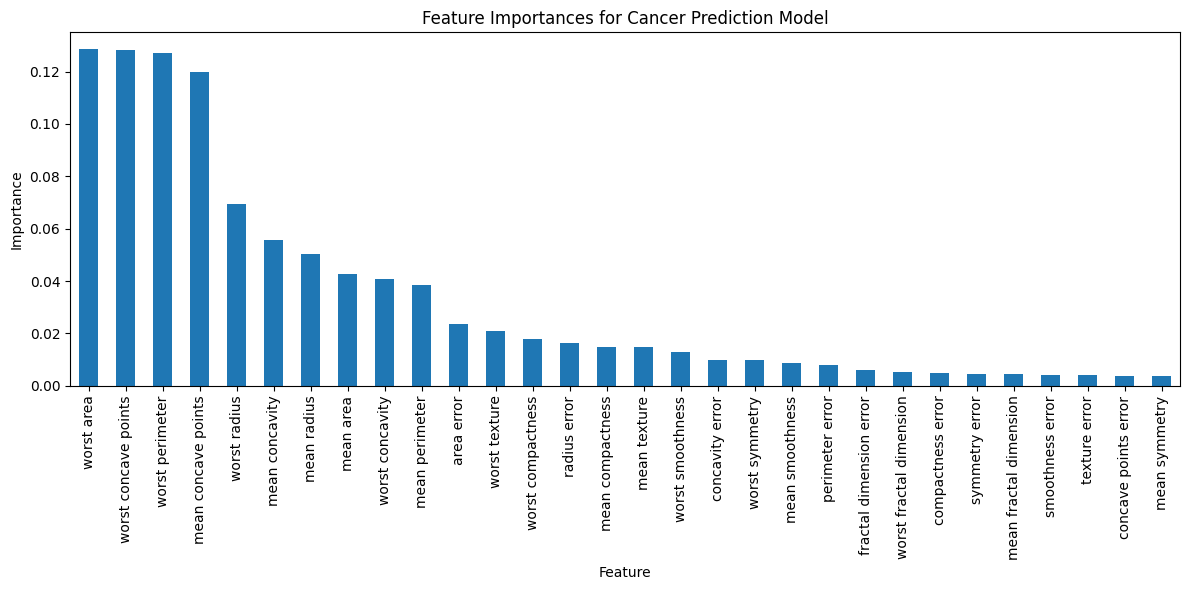

In [0]:
'''
feature_importances_ is a NumPy array of decimal values (one per feature) that represent how much each feature contributed to the model's decision making process.
Array length: Equals the number of input features
Values: Decimals between 0 and 1 that sum to exactly 1.0 (100%)
Interpretation: Higher values = more important for predictions
'''
# Extract feature importances from the underlying sklearn model
if hasattr(model._model_impl, 'sklearn_model'):
    feature_importances = model._model_impl.sklearn_model.feature_importances_
elif hasattr(model._model_impl, 'feature_importances_'):
    feature_importances = model._model_impl.feature_importances_
elif hasattr(model._model_impl, 'coef_'):
    feature_importances = model._model_impl.coef_[0]
else:
    raise AttributeError('The model does not have feature_importances_ or coef_ attribute')

# Define the feature columnss to consider
feature_names = X_test.columns # index of the feature with feature name

# feature_importances is a nnumpy 1Dimension array containing a list of decimals numberss with shape of N nnumber of features
'''
Array Structure
Array Index:0; Importance Value:0.13; Feature Name:worst area
'''
importances = pd.Series(feature_importances, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
importances_sorted.plot.bar()
plt.title("Feature Importances for Cancer Prediction Model")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

## Predict Feature Importances
Featuress can be both numerical or categorical, in this use case we use 30 numerical input features.

Features that consistently separate benign from malignant tumors get high importance. It basically answer the question how useful is this measurement for making a clear yes/no cancer decision?
- Input features (30 measurements)
- Target/label (benign=1 or malignant=0)
The chart reveals which measurements matter most for predicting cancer malignancy:

## Top 4 Most Important Features (0.12-0.13 importance each):

- worst area: The largest area measurement of the tumor
- worst concave points: The most severe concave portions (indentations) in the tumor boundary
- worst perimeter: The largest perimeter measurement
- mean concave points: Average concave portions across measurements

These worst measurements represent the most extreme values detected across multiple cell images. The model is essentially saying that if we detect large tumors with irregular, deeply indented boundaries, that's highly predictive of malignancy.

## Medium Importance Features (0.04-0.07):

- worst radius, mean concavity, mean radius, mean area - Size and shape characteristics
- worst/mean concavity, worst/mean perimeter - Boundary irregularity measures

## Low Importance Features (<0.02):

Texture, smoothness, compactness, symmetry measurements - These contribute less to the final decision

Key Insight: The model learned that tumor size combined with boundary irregularity (especially concave indentations) are the strongest cancer indicators. Malignant tumors tend to be larger with more irregular, jagged boundaries.

## Conclusion
The Random Forest learned that large, irregularly shaped tumors with deep boundary indentations are strong cancer indicators, which is exactly what oncologists look for in diagnostic imaging.

# Test portability of model from exported ZIP folder

Loading model from: ./cancer_model_package/model


2026/07/16 22:21:00 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.8.1, required: mlflow==3.14.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


Model loaded successfully!

Test dataset shape: (114, 30)
Number of test samples: 114

Making predictions...
Predictions complete!

ACCURACY SCORE: 0.9649 (96.49%)

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.93      0.95        43
   Benign (1)       0.96      0.99      0.97        71

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114


CONFUSION MATRIX:
[[40  3]
 [ 1 70]]

Confusion matrix saved as 'confusion_matrix.png'


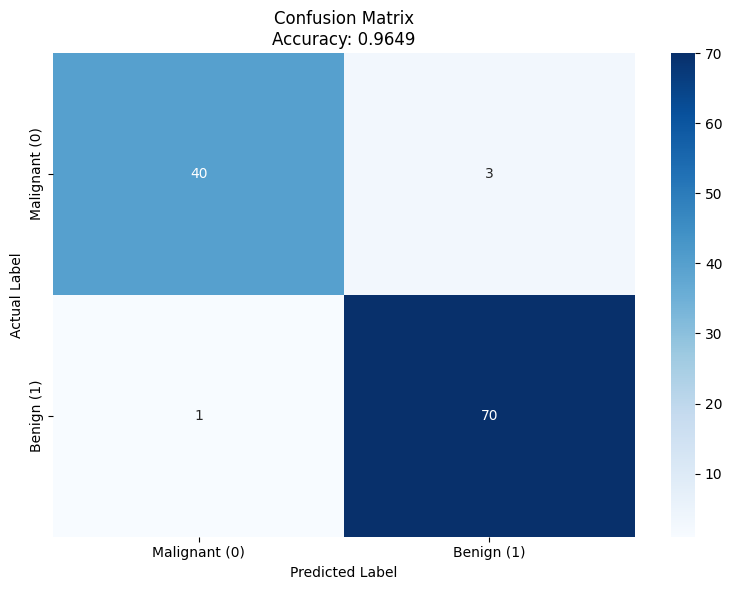


SAMPLE PREDICTIONS (first 10):
Actual_Label Predicted_Label  Match
      Benign          Benign   True
   Malignant       Malignant   True
   Malignant       Malignant   True
      Benign          Benign   True
      Benign          Benign   True
   Malignant       Malignant   True
   Malignant       Malignant   True
   Malignant       Malignant   True
      Benign       Malignant  False
      Benign          Benign   True
SUMMARY: 110/114 correct predictions
Accuracy: 96.49%


In [0]:
# Install dependencies
# !pip install mlflow scikit-learn pandas numpy matplotlib seaborn
import mlflow.pyfunc
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD THE MODEL
# Update this path to cancer_model_package
MODEL_PATH = "./cancer_model_package/model" 
print("Loading model from:", MODEL_PATH)
model = mlflow.pyfunc.load_model(MODEL_PATH)
print("Model loaded successfully!\n")

# LOAD TEST DATA
# Load the same breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split with same random_state to get consistent test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Test dataset shape: {X_test.shape}")
print(f"Number of test samples: {len(y_test)}\n")

# MAKE PREDICTIONS

print("Making predictions...")
y_pred = model.predict(X_test)
print("Predictions complete!\n")

# EVALUATE PERFORMANCE

# Calculate accuracy
accuracy = accuracy_score(y_test, # ground truth labels
                          y_pred # model predictionss
                          )
print(f"ACCURACY SCORE: {accuracy:.4f} ({accuracy*100:.2f}%)")
print()

# Detailed classification report
print("CLASSIFICATION REPORT:")
target_names = ['Malignant (0)', 'Benign (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX:")
print(cm)
print()

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print("Confusion matrix saved as 'confusion_matrix.png'")
plt.show()


# SAMPLE PREDICTIONS
print("\nSAMPLE PREDICTIONS (first 10):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10],
    'Match': y_test[:10] == y_pred[:10]
})
comparison_df['Actual_Label'] = comparison_df['Actual'].map({0: 'Malignant', 1: 'Benign'})
comparison_df['Predicted_Label'] = comparison_df['Predicted'].map({0: 'Malignant', 1: 'Benign'})
print(comparison_df[['Actual_Label', 'Predicted_Label', 'Match']].to_string(index=False))

# Summary
correct = (y_test == y_pred).sum()
total = len(y_test)
print(f"SUMMARY: {correct}/{total} correct predictions")
print(f"Accuracy: {accuracy*100:.2f}%")

# Clinical Implications
- Total errors: 4
- False Negatives (FN): Missed 3 malignant cases
- False Positives (FP): Incorrectly flagged 1 benign case

False Negatives are the critical concern in cancer detection:
3 patients with actual cancer were told they're benign, in healthcare false negatives should be always increase to close to 100%.

The model shows excellent sensitivity (recall):

Malignant recall = 93% (40/43)
Benign recall = 99% (70/71) 
In a real medical setting, we would need to tune even more to minimize false negatives even if it means accepting more false positives (better to err on the side of caution).